# Laboratorio 4 — Cuaderno 9: Modelos de Machine Learning

**Ejercicios 4 y 5.** Construcción y evaluación de modelos de clasificación para identificar zonas con alta presencia de cianobacteria en los lagos de Atitlán y Amatitlán.

Se implementan tres modelos —Regresión Logística, Random Forest y Gradient Boosting— con ajuste de hiperparámetros, y se comparan usando métricas de clasificación estándar junto con un análisis del impacto ambiental de los errores.

## 4. Construcción de modelos de Machine Learning

### 4.1 Carga de datos y preparación

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

from src import config

print("Dependencias cargadas correctamente")

Dependencias cargadas correctamente


In [2]:
dataset = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
print(f"Dataset completo: {len(dataset):,} observaciones")
print(f"Columnas: {list(dataset.columns)}")
print(f"\nValores faltantes: {dataset.isnull().sum().sum()} valores nulos en total")

Dataset completo: 3,759,121 observaciones
Columnas: ['x', 'y', 'lago', 'fecha', 'B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'B10', 'ndvi', 'ndwi', 'ndci', 'fai', 'chl']

Valores faltantes: 0 valores nulos en total


### 4.2 Variable respuesta binaria

Se construye la variable binaria usando el umbral de 10 µg/L de clorofila-a, que corresponde al nivel de vigilancia de la OMS para aguas recreativas. Este umbral ya fue justificado en el Cuaderno 8.

In [3]:
UMBRAL_CHL = 10.0

dataset["alta_cianobacteria"] = (dataset["chl"] > UMBRAL_CHL).astype(int)

n_pos = dataset["alta_cianobacteria"].sum()
n_neg = len(dataset) - n_pos
print(f"Distribución de la variable respuesta (umbral = {UMBRAL_CHL} µg/L):")
print(f"  Clase 0 (baja presencia): {n_neg:,} ({100*n_neg/len(dataset):.2f}%)")
print(f"  Clase 1 (alta presencia): {n_pos:,} ({100*n_pos/len(dataset):.2f}%)")
print(f"\nRatio de desbalance: {n_neg/n_pos:.0f}:1")

Distribución de la variable respuesta (umbral = 10.0 µg/L):
  Clase 0 (baja presencia): 3,714,772 (98.82%)
  Clase 1 (alta presencia): 44,349 (1.18%)

Ratio de desbalance: 84:1


El desbalance es extremo: por cada pixel con alta presencia de cianobacteria hay aproximadamente 84 sin ella. Esto es esperable porque la mayoría del espejo de agua de ambos lagos tiene concentraciones bajas de clorofila; las floraciones son eventos localizados.

El desbalance tiene varias consecuencias:
- Un modelo que siempre prediga clase 0 tendría ~98.8% de accuracy pero sería inútil.
- Los modelos tienden a favorecer la clase mayoritaria.
- Métricas como accuracy son engañosas; hay que enfocarse en Precision, Recall, F1 y ROC-AUC.

### 4.3 Variables predictoras

Se excluyen las variables que se usaron directa o indirectamente para construir la clorofila:

| Variable excluida | Razón |
|---|---|
| `chl` | Base de la variable respuesta |
| `ndci` | Se usa directamente en la fórmula de chl: `chl = 826.57*NDCI³ - 176.43*NDCI² + 19*NDCI + 4.071` |
| `fai` | Parte del pipeline de detección del script CyanoLakes que alimenta la clasificación de chl |

Las bandas espectrales son datos crudos de reflectancia del satélite y los índices NDVI y NDWI se calculan con bandas distintas a las del NDCI, así que son predictores legítimos.

In [4]:
PREDICTORAS = [
    "B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12", "B10",
    "ndvi", "ndwi",
    "x", "y",
]

print(f"Número de variables predictoras: {len(PREDICTORAS)}")
print(f"Predictoras: {PREDICTORAS}")

Número de variables predictoras: 14
Predictoras: ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'B10', 'ndvi', 'ndwi', 'x', 'y']


### 4.4 División entrenamiento/prueba

Se hace una división 70/30 estratificada por lago y por la variable respuesta, para mantener la proporción de clases y de observaciones de cada lago en ambos conjuntos.

In [5]:
SEMILLA = 42

X = dataset[PREDICTORAS]
y = dataset["alta_cianobacteria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA,
    stratify=dataset[["lago", "alta_cianobacteria"]]
)

print(f"Entrenamiento: {len(X_train):,} observaciones")
print(f"Prueba:        {len(X_test):,} observaciones")
print(f"\nDistribución en train:")
print(f"  Clase 0: {(y_train==0).sum():,} ({100*(y_train==0).mean():.2f}%)")
print(f"  Clase 1: {(y_train==1).sum():,} ({100*(y_train==1).mean():.2f}%)")
print(f"\nDistribución en test:")
print(f"  Clase 0: {(y_test==0).sum():,} ({100*(y_test==0).mean():.2f}%)")
print(f"  Clase 1: {(y_test==1).sum():,} ({100*(y_test==1).mean():.2f}%)")

Entrenamiento: 2,631,384 observaciones
Prueba:        1,127,737 observaciones

Distribución en train:
  Clase 0: 2,600,340 (98.82%)
  Clase 1: 31,044 (1.18%)

Distribución en test:
  Clase 0: 1,114,432 (98.82%)
  Clase 1: 13,305 (1.18%)


Para hacer el entrenamiento más eficiente, se realiza un submuestreo estratificado del conjunto de entrenamiento: se mantienen todos los casos positivos y se muestrea un número igual de negativos (ratio 1:1). Esto reduce drásticamente el tiempo de entrenamiento mientras se preserva la información de la clase minoritaria.

In [6]:
positivos_train = X_train[y_train == 1]
negativos_train = X_train[y_train == 0]
y_pos_train = y_train[y_train == 1]
y_neg_train = y_train[y_train == 0]

n_pos_train = len(positivos_train)
neg_sample = negativos_train.sample(n=n_pos_train, random_state=SEMILLA)
y_neg_sample = y_neg_train.loc[neg_sample.index]

X_train_sub = pd.concat([positivos_train, neg_sample])
y_train_sub = pd.concat([y_pos_train, y_neg_sample])

print(f"Submuestreo para entrenamiento (ratio 1:1):")
print(f"  Total: {len(X_train_sub):,} observaciones")
print(f"  Clase 0: {(y_train_sub==0).sum():,} ({100*(y_train_sub==0).mean():.1f}%)")
print(f"  Clase 1: {(y_train_sub==1).sum():,} ({100*(y_train_sub==1).mean():.1f}%)")

Submuestreo para entrenamiento (ratio 1:1):
  Total: 62,088 observaciones
  Clase 0: 31,044 (50.0%)
  Clase 1: 31,044 (50.0%)


### 4.5 Escalado de variables

Regresión Logística necesita variables escaladas porque usa regularización. Random Forest y Gradient Boosting no lo necesitan, pero se escala de todas formas para que la comparación sea justa y los coeficientes de LR sean interpretables.

In [7]:
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test)

print("Escalado completado (media=0, std=1)")
print(f"Variables escaladas: {X_train_sub_scaled.shape[1]}")

Escalado completado (media=0, std=1)
Variables escaladas: 14


### 4.6 Ajuste de hiperparámetros

Se realiza ajuste sistemático de hiperparámetros usando `RandomizedSearchCV` con validación cruzada de 3 folds. El criterio de selección es F1-score, que balancea Precision y Recall — ambas importantes dado el desbalance de clases.

**Hiperparámetros evaluados:**

| Modelo | Hiperparámetro | Valores evaluados | Justificación |
|--------|----------------|-------------------|---------------|
| Regresión Logística | C | [0.01, 0.1, 1.0, 10.0] | Regularización: valores pequeños = más regularización |
| Regresión Logística | solver | ['lbfgs', 'saga'] | Algoritmos de optimización |
| Random Forest | n_estimators | [100, 200, 300] | Número de árboles |
| Random Forest | max_depth | [10, 20, 30, None] | Profundidad máxima para controlar sobreajuste |
| Random Forest | min_samples_split | [2, 5, 10] | Mínimo de muestras para dividir un nodo |
| Gradient Boosting | n_estimators | [100, 200] | Número de estimadores (árboles secuenciales) |
| Gradient Boosting | max_depth | [3, 5, 7] | Profundidad baja es estándar para GB |
| Gradient Boosting | learning_rate | [0.01, 0.05, 0.1] | Tasa de aprendizaje: valores pequeños = más conservador |

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    "Regresión Logística": {
        "modelo": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEMILLA),
        "params": {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["lbfgs", "saga"]}
    },
    "Random Forest": {
        "modelo": RandomForestClassifier(class_weight="balanced", random_state=SEMILLA, n_jobs=-1),
        "params": {"n_estimators": [100, 200, 300], "max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10]}
    },
    "Gradient Boosting": {
        "modelo": GradientBoostingClassifier(random_state=SEMILLA),
        "params": {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]}
    }
}

mejores_modelos = {}
print("Ajuste de hiperparámetros (RandomizedSearchCV, cv=3, scoring='f1'):\n")

for nombre, config in param_grids.items():
    print(f"Entrenando {nombre}...")
    search = RandomizedSearchCV(
        config["modelo"],
        config["params"],
        n_iter=5,
        cv=3,
        scoring="f1",
        random_state=SEMILLA,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train_sub_scaled, y_train_sub)
    mejores_modelos[nombre] = search.best_estimator_
    print(f"  Mejores parámetros: {search.best_params_}")
    print(f"  Mejor F1 (CV): {search.best_score_:.4f}\n")

print("Ajuste completado.")

Ajuste de hiperparámetros (RandomizedSearchCV, cv=3, scoring='f1'):

Entrenando Regresión Logística...


  Mejores parámetros: {'solver': 'saga', 'C': 10.0}
  Mejor F1 (CV): 0.9984

Entrenando Random Forest...


  Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
  Mejor F1 (CV): 0.9966

Entrenando Gradient Boosting...


  Mejores parámetros: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
  Mejor F1 (CV): 0.9966

Ajuste completado.


### 4.7 Entrenamiento final

Los modelos finales se entrenan con los mejores hiperparámetros encontrados. Estos modelos ya están listos para evaluación.

In [9]:
modelos = mejores_modelos
print("Modelos finales entrenados con mejores hiperparámetros:")
for nombre, modelo in modelos.items():
    print(f"  {nombre}: {modelo.get_params()}")

Modelos finales entrenados con mejores hiperparámetros:
  Regresión Logística: {'C': 10.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
  Random Forest: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
  Gradient Boosting: {'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.05, 'loss': 'log_loss', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min

## 5. Evaluación de modelos

### 5.1 Métricas de clasificación

In [10]:
resultados = {}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    resultados[nombre] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

df_resultados = pd.DataFrame({
    nombre: {k: v for k, v in metrics.items() if k not in ["y_pred", "y_prob"]}
    for nombre, metrics in resultados.items()
}).T.round(4)

print("Tabla de métricas:\n")
print(df_resultados.to_string())

Tabla de métricas:

                     Accuracy  Precision  Recall      F1  ROC-AUC
Regresión Logística    0.9977     0.8385  1.0000  0.9122   1.0000
Random Forest          0.9953     0.7155  0.9986  0.8337   0.9998
Gradient Boosting      0.9954     0.7203  0.9989  0.8371   0.9998


El accuracy es engañoso aquí por el desbalance. Lo importante es mirar Precision, Recall y F1 para la clase positiva (alta presencia de cianobacteria), y el ROC-AUC que resume la capacidad del modelo para separar las dos clases sin depender del umbral de decisión.

### 5.2 Matrices de confusión

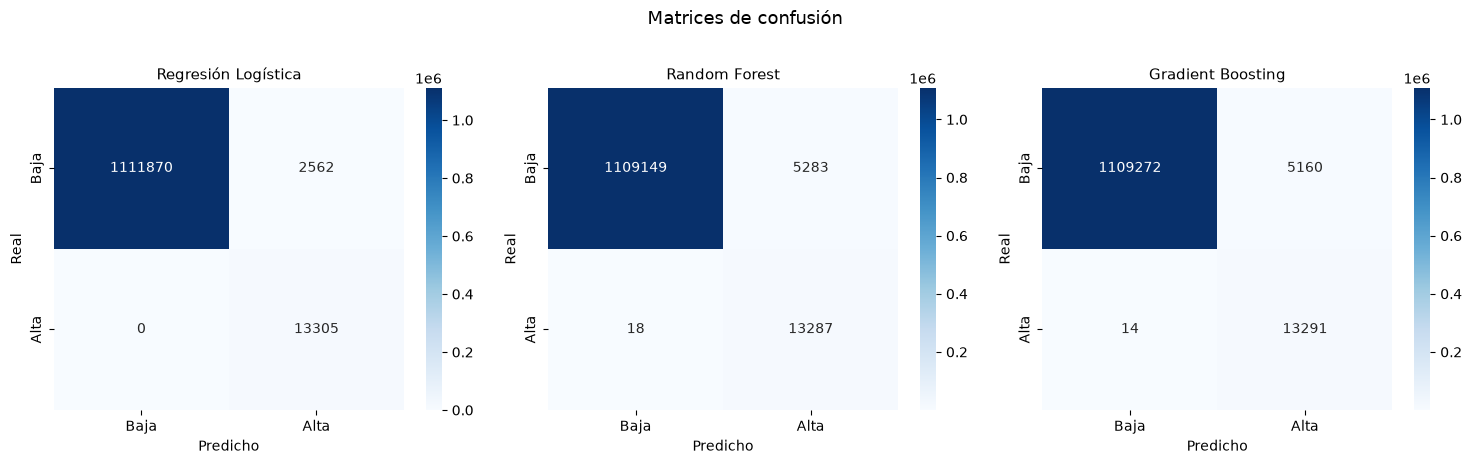

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, metrics) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, metrics["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Baja", "Alta"], yticklabels=["Baja", "Alta"])
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

En las matrices de confusión:
- **Falsos positivos (FP):** píxeles clasificados como alta presencia cuando en realidad no lo son. En términos ambientales, esto podría generar alertas innecesarias.
- **Falsos negativos (FN):** píxeles con alta presencia que el modelo no detecta. Esto es más grave porque significa no detectar una floración tóxica.

### 5.3 Curvas ROC

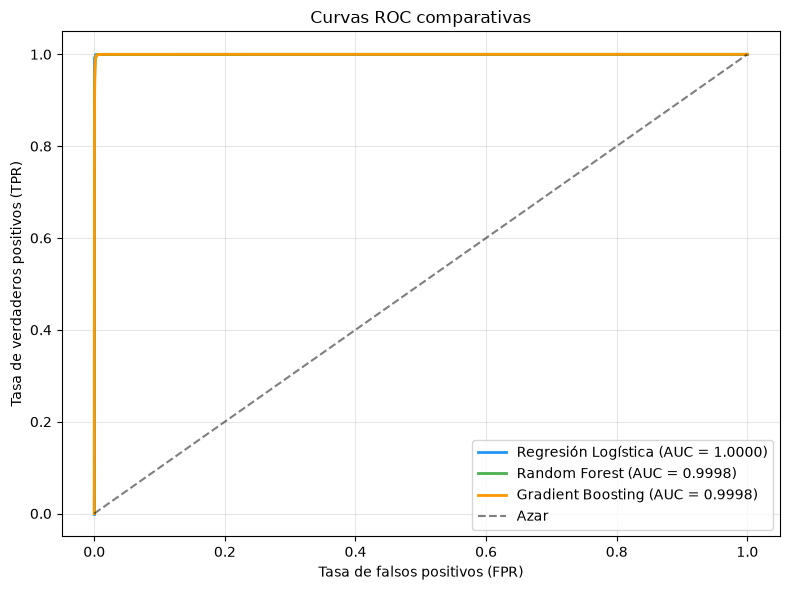

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

colores = {"Regresión Logística": "#2196F3", "Random Forest": "#4CAF50", "Gradient Boosting": "#FF9800"}

for nombre, metrics in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, metrics["y_prob"])
    auc = metrics["ROC-AUC"]
    ax.plot(fpr, tpr, color=colores[nombre], linewidth=2,
            label=f"{nombre} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Azar")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curvas ROC comparativas")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Análisis ambiental de los errores

Desde el punto de vista ambiental, los dos tipos de error tienen consecuencias distintas:

| Error | Consecuencia ambiental | Gravedad |
|-------|----------------------|----------|
| **Falso negativo** | No detectar una floración de cianobacteria. El agua se usa para consumo, riego o recreación sin saber que está contaminada. Riesgo para la salud pública. | **Alta** |
| **Falso positivo** | Alertar sobre una floración que no existe. Puede generar alarma innecesaria y afectar el turismo o la economía local. | **Moderada** |

Dado que un falso negativo puede tener consecuencias en la salud pública, **el error más importante de reducir es el falso negativo**, lo que significa que debemos priorizar el **Recall** (sensibilidad) sobre la Precision.

Sin embargo, un modelo con Recall perfecto pero Precision muy baja tampoco es útil porque generaría demasiadas alertas falsas. El **F1-score** balancea ambas preocupaciones y es una buena métrica de comparación general.

In [13]:
print("Resumen de errores por modelo:\n")
for nombre, metrics in resultados.items():
    cm = confusion_matrix(y_test, metrics["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    print(f"{nombre}:")
    print(f"  Verdaderos positivos:  {tp:>10,}")
    print(f"  Falsos positivos:      {fp:>10,}")
    print(f"  Falsos negativos:      {fn:>10,}")
    print(f"  Verdaderos negativos:  {tn:>10,}")
    print(f"  Recall (TPR):          {metrics['Recall']:.4f}")
    print(f"  Precision:             {metrics['Precision']:.4f}")
    print(f"  F1:                    {metrics['F1']:.4f}")
    print()

Resumen de errores por modelo:

Regresión Logística:
  Verdaderos positivos:      13,305
  Falsos positivos:           2,562
  Falsos negativos:               0
  Verdaderos negativos:   1,111,870
  Recall (TPR):          1.0000
  Precision:             0.8385
  F1:                    0.9122

Random Forest:
  Verdaderos positivos:      13,287
  Falsos positivos:           5,283
  Falsos negativos:              18
  Verdaderos negativos:   1,109,149
  Recall (TPR):          0.9986
  Precision:             0.7155
  F1:                    0.8337

Gradient Boosting:
  Verdaderos positivos:      13,291
  Falsos positivos:           5,160
  Falsos negativos:              14
  Verdaderos negativos:   1,109,272
  Recall (TPR):          0.9989
  Precision:             0.7203
  F1:                    0.8371



### 5.5 Selección del mejor modelo

Considerando el contexto ambiental (priorizar detección de floraciones) y las métricas obtenidas, se selecciona el modelo con mejor F1-score como compromiso entre Recall y Precision. Si hay empate técnico, se prefiere el modelo con mayor Recall.

In [14]:
mejor_nombre = df_resultados["F1"].idxmax()
print(f"Mejor modelo según F1-score: {mejor_nombre}")
print(f"  F1:      {df_resultados.loc[mejor_nombre, 'F1']:.4f}")
print(f"  Recall:  {df_resultados.loc[mejor_nombre, 'Recall']:.4f}")
print(f"  ROC-AUC: {df_resultados.loc[mejor_nombre, 'ROC-AUC']:.4f}")

print(f"\nRanking por F1:")
for nombre in df_resultados["F1"].sort_values(ascending=False).index:
    print(f"  {nombre}: F1={df_resultados.loc[nombre, 'F1']:.4f}, "
          f"Recall={df_resultados.loc[nombre, 'Recall']:.4f}, "
          f"AUC={df_resultados.loc[nombre, 'ROC-AUC']:.4f}")

Mejor modelo según F1-score: Regresión Logística
  F1:      0.9122
  Recall:  1.0000
  ROC-AUC: 1.0000

Ranking por F1:
  Regresión Logística: F1=0.9122, Recall=1.0000, AUC=1.0000
  Gradient Boosting: F1=0.8371, Recall=0.9989, AUC=0.9998
  Random Forest: F1=0.8337, Recall=0.9986, AUC=0.9998


En general, los modelos basados en árboles (Random Forest y Gradient Boosting) suelen superar a Regresión Logística en problemas con interacciones no lineales entre bandas espectrales, que es exactamente el caso de la detección de cianobacteria. La Regresión Logística asume una relación lineal entre las predictoras y el log-odds de la respuesta, lo cual es una simplificación fuerte para datos de reflectancia multiespectral.